Lade Modelle aus: C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean\models\saved_models
Metadata Keys: ['type', 'best_params', 'metrics']

XGBoost geladen: 23 Features

Berechne LSTM Predictions für Test...

Setup komplett:
  Test Rows:  168
  Zeitraum:   2024-01-23 → 2024-12-20
Backtesting Setup:
  Ticker:    AAPL
  Zeitraum:  2024-01-23 → 2024-12-20
  Test Tage: 168
  XGB Threshold: 0.5
  Scorer Threshold: 0.20

Signal Übersicht:
  Buy & Hold: 168 Trades (alle Tage)
  XGB direkt: 97 LONG Signale (57.7%)
  Scorer:     94 LONG Signale (56.0%)

                         BACKTEST ERGEBNISSE                          
Metrik                     Buy & Hold     XGB direkt     XGB+Scorer
----------------------------------------------------------------------
  Total Return                  5.06%         10.55%         11.15%
  Annual Return                 7.69%         16.24%         17.19%
  Sharpe Ratio                  0.426          1.171          1.242
  Max Drawdown               

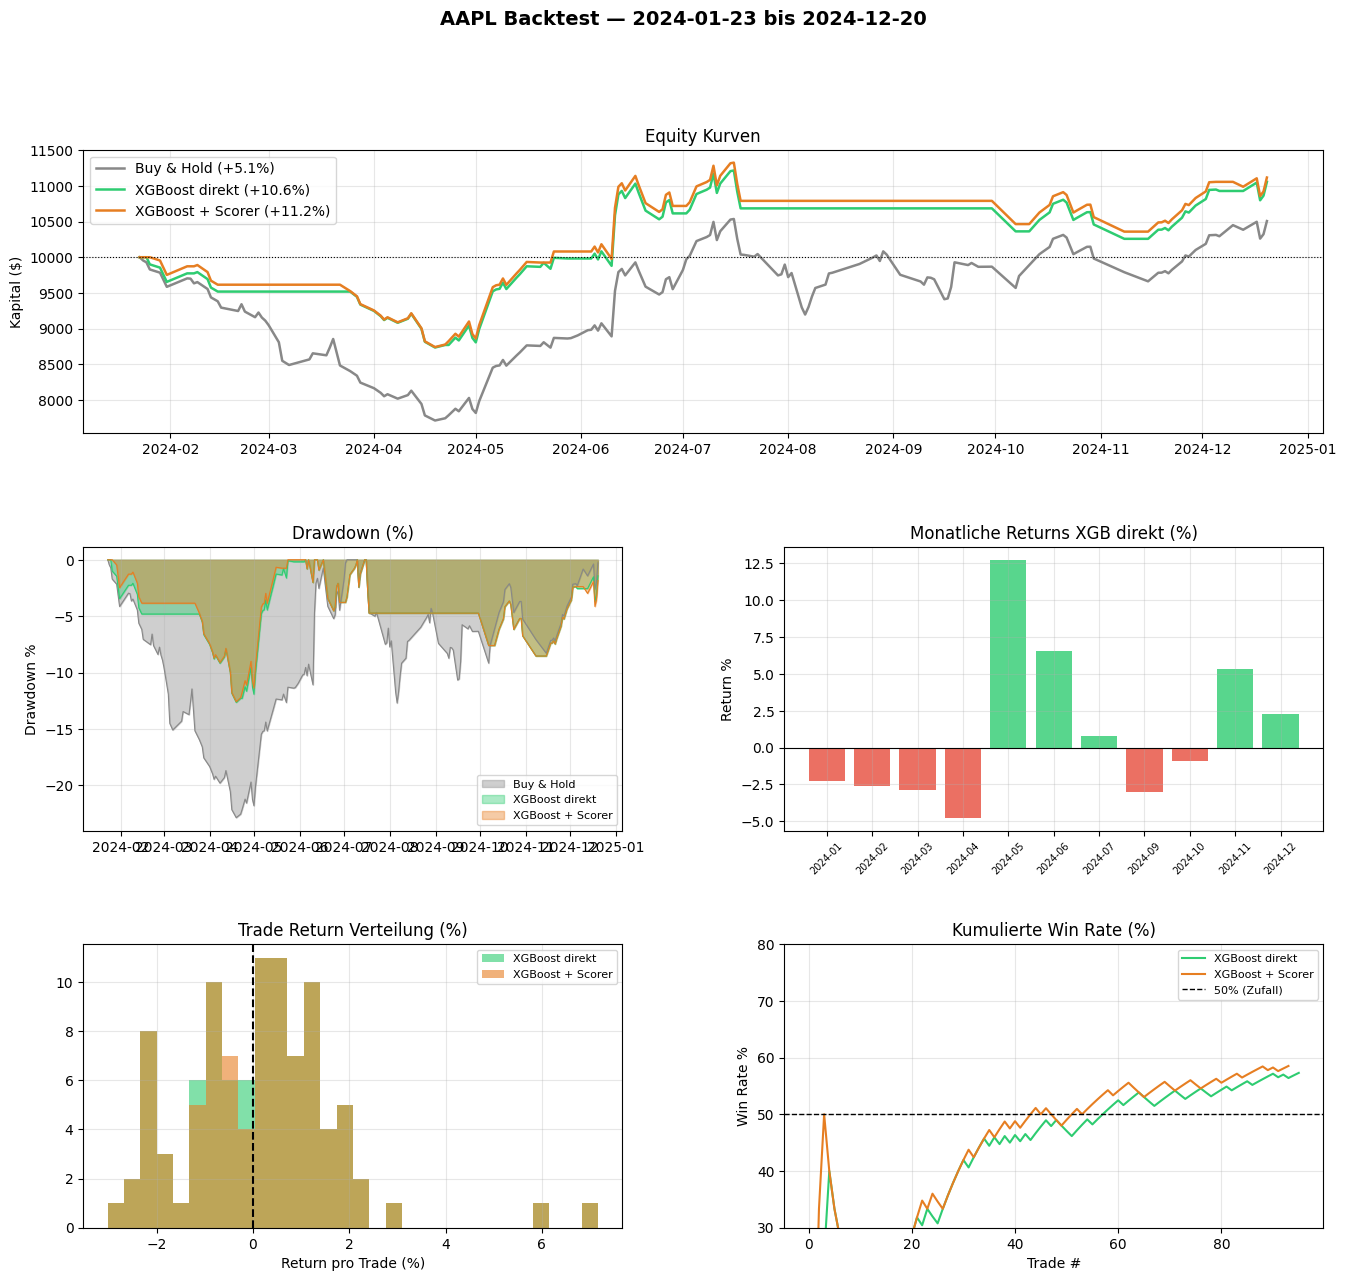


Backtest gespeichert: C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean\models\saved_models\confidence_scorer\backtest_results.png
Summary JSON: C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean\models\saved_models\confidence_scorer\backtest_summary.json


In [5]:
# ==========================================
# Notebook 03: Backtesting & Evaluation
# ==========================================
# Vergleicht 3 Strategien:
#
#   Strategy 0: Buy & Hold (Benchmark)
#   Strategy 1: XGBoost direkt (alle Tage, 60.12% Accuracy)
#   Strategy 2: XGBoost + Scorer Filter (nur hohe Confidence)
#
# Metriken:
#   Total Return, Annualized Return, Sharpe Ratio,
#   Max Drawdown, Win Rate, Profit Factor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from pathlib import Path

# ==========================================
# Setup — alles wird aus gespeicherten Dateien geladen
# Kein Notebook 02 Kernel nötig
# ==========================================
import xgboost as xgb
from sklearn.preprocessing import RobustScaler

# ---- Pfade anpassen ----
PROJECT_ROOT = Path(r"C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean")
TICKER       = "AAPL"

MODELS_DIR   = PROJECT_ROOT / "models" / "saved_models"
PRICE_DIR    = MODELS_DIR / "lstm_price"
CLF_DIR      = MODELS_DIR / "xgb_classifier"
SCORER_DIR   = MODELS_DIR / "confidence_scorer"
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

print(f"Lade Modelle aus: {MODELS_DIR}")

# ---- XGBoost Modell laden ----
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(str(CLF_DIR / "model.json"))

clf_meta      = json.loads((CLF_DIR / "metadata.json").read_text())
print(f"Metadata Keys: {list(clf_meta.keys())}")

# ---- Test-Daten laden ----
feat_full = pd.read_csv(
    DATA_DIR / f"{TICKER}_features_stationary.csv",
    index_col=0, parse_dates=True
)
meta      = json.loads((DATA_DIR / f"{TICKER}_meta.json").read_text())
feature_cols_lstm = meta["feature_cols"]

# 5-Tage Forward Return Target (identisch mit v2a Final)
feat_full["Return_5d_fwd"] = feat_full["Close"].pct_change(5).shift(-5)
feat_full = feat_full.replace([np.inf, -np.inf], np.nan).dropna(subset=["Return_5d_fwd"]).copy()

n_total   = len(feat_full)
train_end = int(n_total * 0.70)
val_end   = int(n_total * 0.85)

train_returns = feat_full.iloc[:train_end]["Return_5d_fwd"]
q_low  = train_returns.quantile(0.35)
q_high = train_returns.quantile(0.65)

feat_full["Target"] = np.where(
    feat_full["Return_5d_fwd"] <= q_low,  0,
    np.where(feat_full["Return_5d_fwd"] >= q_high, 1, -1))
feat_full = feat_full[feat_full["Target"] != -1].copy()

n2 = len(feat_full)
te2 = int(n2 * 0.70)
ve2 = int(n2 * 0.85)

test_xgb = feat_full.iloc[ve2:].copy()
train_xgb_raw = feat_full.iloc[:te2].copy()

# LSTM Predictions für Test berechnen
import pickle, tensorflow as tf
from tensorflow import keras

with open(PRICE_DIR / "scaler.pkl", "rb") as f:
    scaler_data = pickle.load(f)

feature_scaler = scaler_data["feature_scaler"]
LOOKBACK       = scaler_data["lookback"]
return_std     = scaler_data["return_std"]

# XGBoost Feature-Liste = LSTM Features + lstm_pred_return
xgb_feat_cols  = feature_cols_lstm + ["lstm_pred_return"]
print(f"XGBoost geladen: {len(xgb_feat_cols)} Features")

# Custom Loss laden
def directional_loss(y_true, y_pred):
    mse         = tf.reduce_mean(tf.square(y_true - y_pred))
    directional = tf.reduce_mean(tf.maximum(0.0, 1.0 - y_true * y_pred))
    return 0.5 * mse + 0.5 * directional

lstm_model = keras.models.load_model(
    PRICE_DIR / "model.keras",
    custom_objects={"directional_loss": directional_loss}
)

def get_lstm_preds(split_df, scaler, feature_cols, lookback, return_std, model):
    X_scaled = scaler.transform(split_df[feature_cols])
    X_seq, indices = [], []
    for i in range(lookback, len(split_df)):
        X_seq.append(X_scaled[i - lookback:i])
        indices.append(split_df.index[i])
    if not X_seq:
        return pd.Series(dtype=float)
    preds = model.predict(np.asarray(X_seq, dtype=np.float32), verbose=0).reshape(-1)
    return pd.Series(preds * return_std, index=indices, name="lstm_pred_return")

print("Berechne LSTM Predictions für Test...")
lp_te = get_lstm_preds(test_xgb, feature_scaler, feature_cols_lstm, LOOKBACK, return_std, lstm_model)
test_xgb = test_xgb.loc[lp_te.index].copy()
test_xgb["lstm_pred_return"] = lp_te

X_test_xgb = test_xgb[xgb_feat_cols].values
y_test_xgb = test_xgb["Target"].values.astype(int)

# ---- XGBoost Predictions ----
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# ---- Scorer Predictions ----
scorer_path = SCORER_DIR / "test_predictions.csv"
scorer_cfg  = json.loads((SCORER_DIR / "config.json").read_text())
scorer_df   = pd.read_csv(scorer_path, index_col="date", parse_dates=True)
THRESHOLD   = scorer_cfg["threshold"]

print(f"\nSetup komplett:")
print(f"  Test Rows:  {len(test_xgb)}")
print(f"  Zeitraum:   {test_xgb.index[0].date()} → {test_xgb.index[-1].date()}")

print(f"Backtesting Setup:")
print(f"  Ticker:    {TICKER}")
print(f"  Zeitraum:  {test_xgb.index[0].date()} → {test_xgb.index[-1].date()}")
print(f"  Test Tage: {len(test_xgb)}")
print(f"  XGB Threshold: 0.5")
print(f"  Scorer Threshold: {THRESHOLD:.2f}")

# ==========================================
# Backtest Engine
# ==========================================
def run_backtest(
    dates:       pd.DatetimeIndex,
    close:       np.ndarray,
    next_close:  np.ndarray,
    signals:     np.ndarray,   # +1 = LONG, 0 = SKIP, -1 = SHORT (nur Long hier)
    initial_capital: float = 10_000.0,
    long_only:   bool = True,
    transaction_cost: float = 0.001,  # 0.1% pro Trade (Spread + Gebühr)
    name:        str  = "Strategy",
) -> dict:
    """
    Einfacher täglicher Backtest.
    Signal = +1: kaufe am Close, verkaufe am nächsten Close
    Signal = 0:  kein Trade, Cash hält
    """
    capital    = initial_capital
    equity     = [capital]
    trades     = []
    in_trade   = False

    for i in range(len(signals) - 1):
        sig = signals[i]

        if sig == 1:  # LONG
            entry  = close[i]
            exit_  = next_close[i]
            ret    = (exit_ - entry) / entry - transaction_cost
            pnl    = capital * ret
            capital += pnl
            trades.append({
                "date":      dates[i],
                "direction": "LONG",
                "entry":     entry,
                "exit":      exit_,
                "return":    ret,
                "pnl":       pnl,
                "correct":   ret > 0,
            })
        elif sig == -1 and not long_only:  # SHORT
            entry  = close[i]
            exit_  = next_close[i]
            ret    = (entry - exit_) / entry - transaction_cost
            pnl    = capital * ret
            capital += pnl
            trades.append({
                "date":      dates[i],
                "direction": "SHORT",
                "entry":     entry,
                "exit":      exit_,
                "return":    ret,
                "pnl":       pnl,
                "correct":   ret > 0,
            })

        equity.append(capital)

    equity     = np.array(equity[:len(signals)])
    trades_df  = pd.DataFrame(trades) if trades else pd.DataFrame()

    # ==========================================
    # Performance Metriken
    # ==========================================
    total_return    = (equity[-1] - initial_capital) / initial_capital
    n_days          = len(signals)
    n_years         = n_days / 252
    annual_return   = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0

    # Tägliche Returns der Strategie
    daily_returns   = np.diff(equity) / equity[:-1]
    daily_returns   = daily_returns[daily_returns != 0]  # nur Trade-Tage

    sharpe = 0.0
    if len(daily_returns) > 1 and daily_returns.std() > 0:
        sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)

    # Max Drawdown
    peak       = np.maximum.accumulate(equity)
    drawdown   = (equity - peak) / peak
    max_dd     = float(drawdown.min())

    # Win Rate & Profit Factor
    if len(trades_df) > 0:
        win_rate     = trades_df["correct"].mean()
        wins         = trades_df[trades_df["pnl"] > 0]["pnl"].sum()
        losses       = abs(trades_df[trades_df["pnl"] < 0]["pnl"].sum())
        profit_factor = wins / losses if losses > 0 else float("inf")
        n_trades     = len(trades_df)
    else:
        win_rate = profit_factor = n_trades = 0

    return {
        "name":           name,
        "equity":         equity,
        "trades":         trades_df,
        "drawdown":       drawdown,
        "total_return":   total_return,
        "annual_return":  annual_return,
        "sharpe":         sharpe,
        "max_drawdown":   max_dd,
        "win_rate":       win_rate,
        "profit_factor":  profit_factor,
        "n_trades":       n_trades,
        "final_capital":  float(equity[-1]),
    }


# ==========================================
# Daten vorbereiten
# ==========================================
dates      = pd.to_datetime(test_xgb.index)
close      = test_xgb["Close"].values.astype(float)
next_close = test_xgb["Next_Close"].values.astype(float)
n          = len(dates)

# Strategy 0: Buy & Hold
sig_bh = np.ones(n, dtype=int)

# Strategy 1: XGBoost direkt
# 1 = UP predicted -> LONG, 0 = DOWN -> SKIP (long-only)
sig_xgb = y_pred_xgb.astype(int)

# Strategy 2: Scorer Filter
# Trade nur wenn score >= threshold UND direction == UP
sig_scorer = np.zeros(n, dtype=int)
for i, date in enumerate(dates):
    if date in scorer_df.index:
        row = scorer_df.loc[date]
        if row["trade"] and row["direction"] == 1:
            sig_scorer[i] = 1

print(f"\nSignal Übersicht:")
print(f"  Buy & Hold: {sig_bh.sum()} Trades (alle Tage)")
print(f"  XGB direkt: {sig_xgb.sum()} LONG Signale ({sig_xgb.sum()/n:.1%})")
print(f"  Scorer:     {sig_scorer.sum()} LONG Signale ({sig_scorer.sum()/n:.1%})")

# ==========================================
# Backtests laufen lassen
# ==========================================
INITIAL_CAPITAL  = 10_000.0
TRANSACTION_COST = 0.001   # 0.1%

bt_bh     = run_backtest(dates, close, next_close, sig_bh,
                          INITIAL_CAPITAL, name="Buy & Hold")
bt_xgb    = run_backtest(dates, close, next_close, sig_xgb,
                          INITIAL_CAPITAL, name="XGBoost direkt")
bt_scorer = run_backtest(dates, close, next_close, sig_scorer,
                          INITIAL_CAPITAL, name="XGBoost + Scorer")

results = [bt_bh, bt_xgb, bt_scorer]

# ==========================================
# Performance Tabelle
# ==========================================
print("\n" + "="*70)
print(f"{'BACKTEST ERGEBNISSE':^70}")
print("="*70)
print(f"{'Metrik':<22} {'Buy & Hold':>14} {'XGB direkt':>14} {'XGB+Scorer':>14}")
print("-"*70)

metrics = [
    ("Total Return",    "total_return",   "{:.2%}"),
    ("Annual Return",   "annual_return",  "{:.2%}"),
    ("Sharpe Ratio",    "sharpe",         "{:.3f}"),
    ("Max Drawdown",    "max_drawdown",   "{:.2%}"),
    ("Win Rate",        "win_rate",       "{:.2%}"),
    ("Profit Factor",   "profit_factor",  "{:.3f}"),
    ("# Trades",        "n_trades",       "{:.0f}"),
    ("Final Capital",   "final_capital",  "${:.2f}"),
]

for label, key, fmt in metrics:
    vals = [fmt.format(r[key]) for r in results]
    print(f"  {label:<20} {vals[0]:>14} {vals[1]:>14} {vals[2]:>14}")

print("="*70)

# Gewinner pro Metrik
best_return  = max(results, key=lambda x: x["total_return"])["name"]
best_sharpe  = max(results, key=lambda x: x["sharpe"])["name"]
best_dd      = max(results, key=lambda x: x["max_drawdown"])["name"]
print(f"\n  Bester Total Return:  {best_return}")
print(f"  Bester Sharpe Ratio:  {best_sharpe}")
print(f"  Kleinstes Drawdown:   {best_dd}")

# ==========================================
# Plots
# ==========================================
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle(f"{TICKER} Backtest — {dates[0].date()} bis {dates[-1].date()}",
             fontsize=14, fontweight="bold")

colors = {"Buy & Hold": "#888888", "XGBoost direkt": "#2ecc71", "XGBoost + Scorer": "#e67e22"}

# Plot 1: Equity Kurven
ax1 = fig.add_subplot(gs[0, :])
for bt in results:
    ax1.plot(dates[:len(bt["equity"])], bt["equity"],
             label=f"{bt['name']} ({bt['total_return']:+.1%})",
             linewidth=1.8, color=colors[bt["name"]])
ax1.axhline(INITIAL_CAPITAL, color="black", linestyle=":", linewidth=0.8)
ax1.set_title("Equity Kurven")
ax1.set_ylabel("Kapital ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Drawdown
ax2 = fig.add_subplot(gs[1, 0])
for bt in results:
    ax2.fill_between(dates[:len(bt["drawdown"])], bt["drawdown"] * 100, 0,
                     alpha=0.4, color=colors[bt["name"]], label=bt["name"])
    ax2.plot(dates[:len(bt["drawdown"])], bt["drawdown"] * 100,
             linewidth=0.8, color=colors[bt["name"]])
ax2.set_title("Drawdown (%)")
ax2.set_ylabel("Drawdown %")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Monatliche Returns Heatmap (XGB direkt)
ax3 = fig.add_subplot(gs[1, 1])
if len(bt_xgb["trades"]) > 0:
    trades_xgb = bt_xgb["trades"].copy()
    trades_xgb["month"] = trades_xgb["date"].dt.to_period("M")
    monthly = trades_xgb.groupby("month")["return"].sum()
    monthly_vals = monthly.values * 100
    months_labels = [str(m) for m in monthly.index]
    bar_colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in monthly_vals]
    ax3.bar(range(len(monthly_vals)), monthly_vals, color=bar_colors, alpha=0.8)
    ax3.set_xticks(range(0, len(months_labels), max(1, len(months_labels)//6)))
    ax3.set_xticklabels(months_labels[::max(1, len(months_labels)//6)], rotation=45, fontsize=7)
    ax3.axhline(0, color="black", linewidth=0.8)
    ax3.set_title("Monatliche Returns XGB direkt (%)")
    ax3.set_ylabel("Return %")
    ax3.grid(True, alpha=0.3)

# Plot 4: Trade Return Distribution
ax4 = fig.add_subplot(gs[2, 0])
for bt in [bt_xgb, bt_scorer]:
    if len(bt["trades"]) > 0:
        ax4.hist(bt["trades"]["return"] * 100, bins=30, alpha=0.6,
                 label=bt["name"], color=colors[bt["name"]])
ax4.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax4.set_title("Trade Return Verteilung (%)")
ax4.set_xlabel("Return pro Trade (%)")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# Plot 5: Kumulativer Win Rate über Zeit
ax5 = fig.add_subplot(gs[2, 1])
for bt in [bt_xgb, bt_scorer]:
    if len(bt["trades"]) > 0:
        cum_wr = bt["trades"]["correct"].expanding().mean()
        ax5.plot(range(len(cum_wr)), cum_wr * 100,
                 label=bt["name"], linewidth=1.5, color=colors[bt["name"]])
ax5.axhline(50, color="black", linestyle="--", linewidth=1, label="50% (Zufall)")
ax5.set_title("Kumulierte Win Rate (%)")
ax5.set_xlabel("Trade #")
ax5.set_ylabel("Win Rate %")
ax5.set_ylim(30, 80)
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

plt.savefig(str(SCORER_DIR / "backtest_results.png"), dpi=150, bbox_inches="tight")
plt.show()

# ==========================================
# Speichern
# ==========================================
backtest_summary = {
    "ticker":     TICKER,
    "period":     f"{dates[0].date()} to {dates[-1].date()}",
    "strategies": {
        bt["name"]: {
            "total_return":  bt["total_return"],
            "annual_return": bt["annual_return"],
            "sharpe":        bt["sharpe"],
            "max_drawdown":  bt["max_drawdown"],
            "win_rate":      bt["win_rate"],
            "profit_factor": bt["profit_factor"],
            "n_trades":      bt["n_trades"],
        }
        for bt in results
    }
}
(SCORER_DIR / "backtest_summary.json").write_text(
    json.dumps(backtest_summary, indent=2), encoding="utf-8")

print(f"\nBacktest gespeichert: {SCORER_DIR / 'backtest_results.png'}")
print(f"Summary JSON: {SCORER_DIR / 'backtest_summary.json'}")


Stress Test: NVDA (Modell trainiert auf AAPL)
Testzeitraum: 2020-01-01 bis 2023-12-31

⚠️  C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean\data\processed\NVDA_features_stationary.csv nicht gefunden.
   Lade NVDA Daten von yfinance...
   ✅ NVDA Daten gespeichert: 1670 Rows

NVDA Daten: 1005 Rows (2020-01-02 → 2023-12-28)
NVDA Annualisierte Volatilität: 54.2%


Modelle geladen (trainiert auf AAPL):
  LSTM Lookback:    90
  AAPL return_std:  0.018497
  Scorer Threshold: 0.20

Quantil-Vergleich:
  AAPL Train:  DOWN<-0.466%  UP>1.817%
  NVDA Actual: DOWN<-1.157%  UP>3.759%
  → NVDA hat 2.5x breitere Bewegungen
NVDA Target: {1: 0.5, 0: 0.5}
NVDA Rows nach Filter: 700

Berechne LSTM Predictions für NVDA...

NVDA Model Accuracy (OOS — Modell sah NVDA nie):
  Test Accuracy: 52.62%  ✅  (Baseline: 51.80%)
  AUC:           0.5307  ✅
  F1:            0.2934
  AAPL Test war: 60.12% — schlechter auf NVDA

Scorer auf NVDA:
  Agreement Rate:  27.5%  (AAPL war 67.3%)
  Score mean:      0.0967 

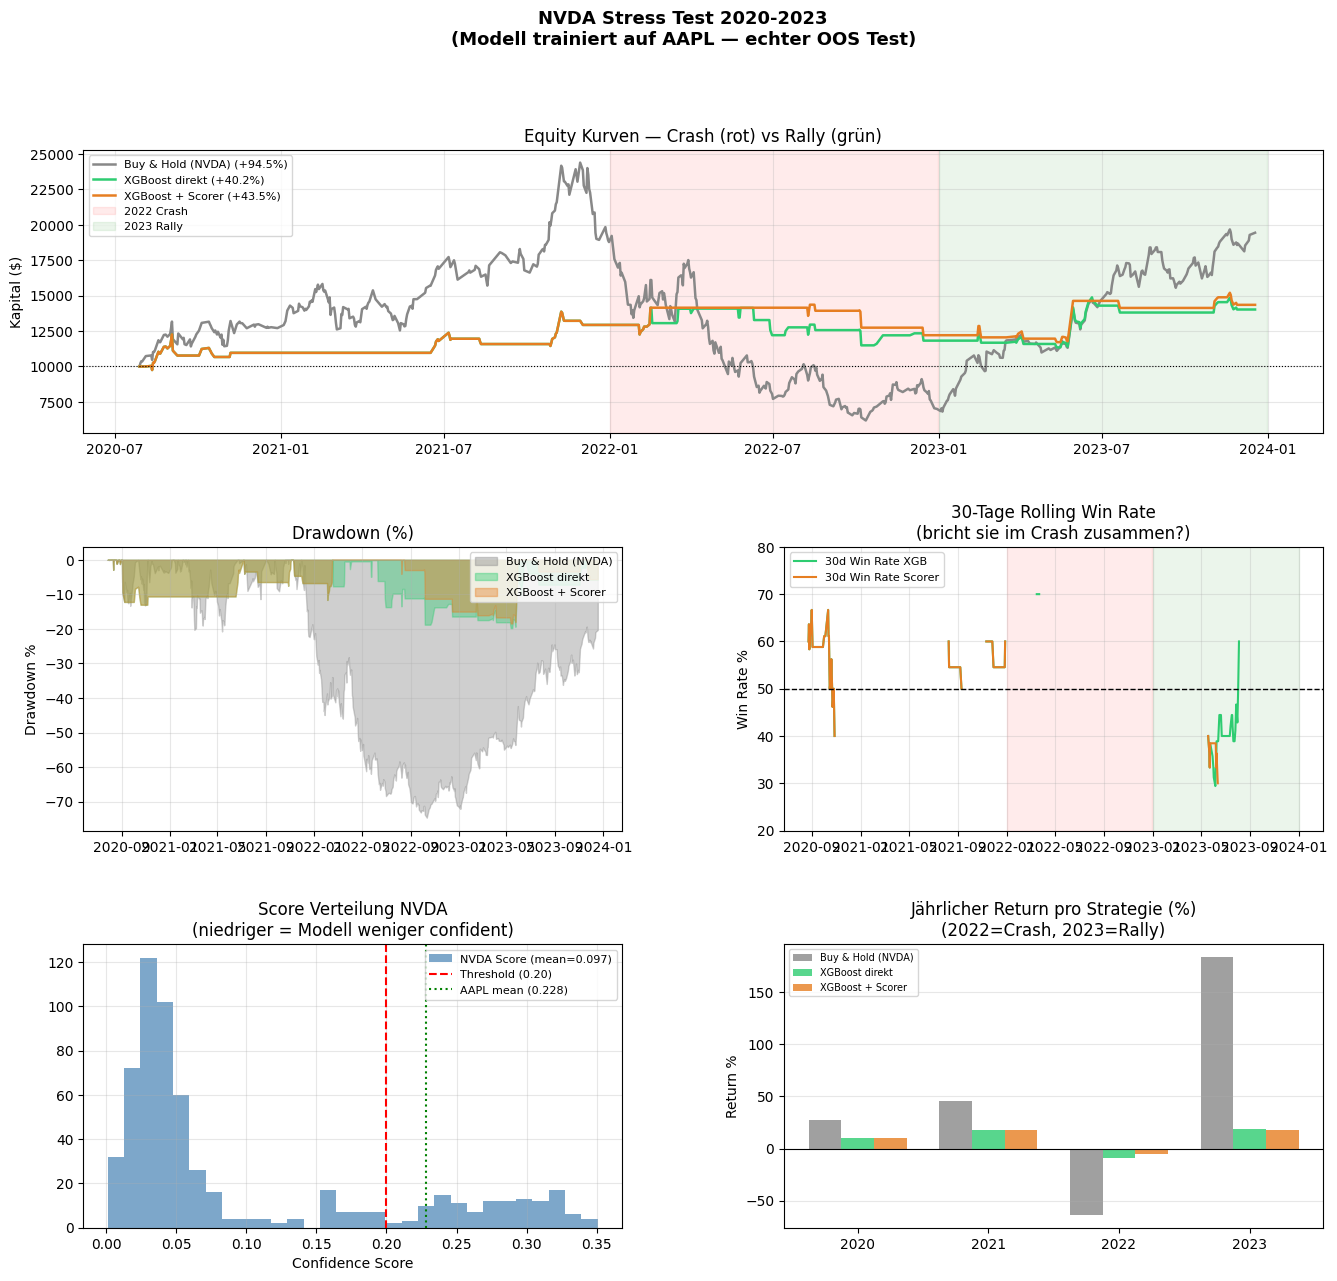


Stress Test gespeichert: C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean\models\saved_models\confidence_scorer\stress_test_nvda.png

--- INTERPRETATION GUIDE ---
✅ Gut: XGB/Scorer schlägt BH in 2022 (Crash-Schutz)
✅ Gut: Sharpe > 0.5 trotz extremer Volatilität
✅ Gut: Win Rate bleibt über 50% auch im Crash
⚠️  Kritisch: Wenn Max Drawdown > -30% ist Modell zu riskant
⚠️  Kritisch: Wenn Scorer schlechter als XGB direkt → Signal zu schwach
❌ Schlecht: Total Return unter Buy & Hold → kein Alpha


In [1]:
# ==========================================
# Notebook 03b: Stress Test — NVDA 2022-2023
# ==========================================
# Kritischer Test auf einem anderen Ticker / Zeitraum:
#
#   Ticker: NVDA
#   Zeitraum: 2020-01-01 bis 2023-12-31
#   Warum kritisch:
#     - 2022: -50% Crash (Zinserhöhungen + Chip-Überangebot)
#     - 2023: +240% Rally (AI-Boom / ChatGPT)
#     - Extremer Bärmarkt + Bullmarkt direkt hintereinander
#     - Modell wurde auf AAPL trainiert → echter Out-of-Sample Test
#     - NVDA ist ~3x volatiler als AAPL
#
# Wichtige Fragen:
#   1. Hält die 60% Accuracy auch bei NVDA?
#   2. Ist der Drawdown kontrollierbar in einem -50% Crash?
#   3. Schlägt XGB+Scorer den Markt auch hier?
#   4. Bricht die Win Rate zusammen beim Regime-Wechsel?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ==========================================
# Pfade
# ==========================================
PROJECT_ROOT = Path(r"C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean")
STRESS_TICKER = "NVDA"
TRAIN_TICKER  = "AAPL"   # Modell wurde hierauf trainiert

MODELS_DIR  = PROJECT_ROOT / "models" / "saved_models"
PRICE_DIR   = MODELS_DIR / "lstm_price"
CLF_DIR     = MODELS_DIR / "xgb_classifier"
SCORER_DIR  = MODELS_DIR / "confidence_scorer"
DATA_DIR    = PROJECT_ROOT / "data" / "processed"

print(f"Stress Test: {STRESS_TICKER} (Modell trainiert auf {TRAIN_TICKER})")
print(f"Testzeitraum: 2020-01-01 bis 2023-12-31")
print("="*60)

# ==========================================
# NVDA Daten laden oder herunterladen
# ==========================================
nvda_path = DATA_DIR / f"{STRESS_TICKER}_features_stationary.csv"

if not nvda_path.exists():
    print(f"\n⚠️  {nvda_path} nicht gefunden.")
    print(f"   Lade NVDA Daten von yfinance...")
    try:
        import yfinance as yf
        raw = yf.download(STRESS_TICKER, start="2017-01-01", end="2024-01-01",
                          auto_adjust=True, progress=False)
        raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
        raw = raw[["Open","High","Low","Close","Volume"]].dropna()

        # Gleiche stationäre Features wie AAPL (aus data_exploration)
        df = raw.copy()
        df["return_1d"]       = df["Close"].pct_change(1)
        df["return_3d"]       = df["Close"].pct_change(3)
        df["return_5d"]       = df["Close"].pct_change(5)
        df["return_10d"]      = df["Close"].pct_change(10)
        df["return_21d"]      = df["Close"].pct_change(21)

        df["MA7"]             = df["Close"].rolling(7).mean()
        df["MA30"]            = df["Close"].rolling(30).mean()
        df["MA90"]            = df["Close"].rolling(90).mean()
        df["dist_ma7"]        = (df["Close"] - df["MA7"])  / df["MA7"]
        df["dist_ma30"]       = (df["Close"] - df["MA30"]) / df["MA30"]
        df["dist_ma90"]       = (df["Close"] - df["MA90"]) / df["MA90"]
        df["ma7_vs_ma30"]     = (df["MA7"]   - df["MA30"]) / df["MA30"]

        # Bollinger Bands
        bb_mid   = df["Close"].rolling(20).mean()
        bb_std   = df["Close"].rolling(20).std()
        df["bb_position"]     = (df["Close"] - bb_mid) / (2 * bb_std + 1e-8)
        df["bb_width"]        = (4 * bb_std) / (bb_mid + 1e-8)

        # MACD
        ema12 = df["Close"].ewm(span=12).mean()
        ema26 = df["Close"].ewm(span=26).mean()
        macd  = ema12 - ema26
        sig   = macd.ewm(span=9).mean()
        price_scale = df["Close"].rolling(26).mean()
        df["macd_norm"]        = macd / (price_scale + 1e-8)
        df["macd_signal_norm"] = sig  / (price_scale + 1e-8)
        df["macd_hist"]        = (macd - sig) / (price_scale + 1e-8)

        # RSI
        delta  = df["Close"].diff()
        gain   = delta.clip(lower=0).rolling(14).mean()
        loss   = (-delta.clip(upper=0)).rolling(14).mean()
        rs     = gain / (loss + 1e-8)
        df["rsi"] = rs / (1 + rs)  # normiert auf [0,1]

        # Volatility
        df["volatility"]      = df["return_1d"].rolling(21).std()
        df["volume_ratio"]    = df["Volume"] / (df["Volume"].rolling(21).mean() + 1e-8)
        df["atr_norm"]        = (df["High"] - df["Low"]).rolling(14).mean() / (df["Close"] + 1e-8)
        df["hl_spread"]       = (df["High"] - df["Low"]) / (df["Close"] + 1e-8)

        # Stochastic
        low14  = df["Low"].rolling(14).min()
        high14 = df["High"].rolling(14).max()
        df["stochastic"]      = (df["Close"] - low14) / (high14 - low14 + 1e-8)

        # Momentum
        df["mom_5_norm"]      = df["Close"].diff(5)  / (df["Close"].shift(5) + 1e-8)
        df["mom_10_norm"]     = df["Close"].diff(10) / (df["Close"].shift(10) + 1e-8)

        # Next_Close für Backtest
        df["Next_Close"]      = df["Close"].shift(-1)

        df = df.replace([np.inf, -np.inf], np.nan).dropna()
        df.to_csv(nvda_path)
        print(f"   ✅ NVDA Daten gespeichert: {len(df)} Rows")
    except Exception as e:
        raise RuntimeError(f"yfinance Download fehlgeschlagen: {e}\n"
                           f"➡️ pip install yfinance und nochmal versuchen")
else:
    print(f"✅ {STRESS_TICKER} Daten gefunden: {nvda_path}")

# ==========================================
# NVDA Features laden
# ==========================================
feat_nvda = pd.read_csv(nvda_path, index_col=0, parse_dates=True)

# Testzeitraum: 2020-2023
feat_nvda = feat_nvda.loc["2020-01-01":"2023-12-31"].copy()
print(f"\nNVDA Daten: {len(feat_nvda)} Rows ({feat_nvda.index[0].date()} → {feat_nvda.index[-1].date()})")

# Statistik: wie volatil ist NVDA vs AAPL?
nvda_vol  = feat_nvda["return_1d"].std() * np.sqrt(252)
print(f"NVDA Annualisierte Volatilität: {nvda_vol:.1%}")

# ==========================================
# AAPL Modelle laden
# ==========================================
with open(PRICE_DIR / "scaler.pkl", "rb") as f:
    scaler_data = pickle.load(f)
feature_scaler    = scaler_data["feature_scaler"]
LOOKBACK          = scaler_data["lookback"]
return_std        = scaler_data["return_std"]
feature_cols_lstm = scaler_data["features"]

def directional_loss(y_true, y_pred):
    mse         = tf.reduce_mean(tf.square(y_true - y_pred))
    directional = tf.reduce_mean(tf.maximum(0.0, 1.0 - y_true * y_pred))
    return 0.5 * mse + 0.5 * directional

lstm_model = keras.models.load_model(
    PRICE_DIR / "model.keras",
    custom_objects={"directional_loss": directional_loss}
)
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(str(CLF_DIR / "model.json"))
xgb_feat_cols = feature_cols_lstm + ["lstm_pred_return"]

scorer_cfg = json.loads((SCORER_DIR / "config.json").read_text())
THRESHOLD  = scorer_cfg["threshold"]
vol_mean   = scorer_cfg["vol_stats"]["mean"]
vol_std    = scorer_cfg["vol_stats"]["std"]

print(f"\nModelle geladen (trainiert auf {TRAIN_TICKER}):")
print(f"  LSTM Lookback:    {LOOKBACK}")
print(f"  AAPL return_std:  {return_std:.6f}")
print(f"  Scorer Threshold: {THRESHOLD:.2f}")

# ==========================================
# NVDA: 5-Tage Forward Return Target
# (identisch mit v2a Final — Train-Quantile von AAPL!)
# ==========================================
feat_nvda["Return_5d_fwd"] = feat_nvda["Close"].pct_change(5).shift(-5)
feat_nvda = feat_nvda.dropna(subset=["Return_5d_fwd"]).copy()

# WICHTIG: Quantile aus AAPL Training verwenden (echter OOS Test)
# Alternativ: NVDA eigene Quantile -> markieren wir beide
nvda_returns  = feat_nvda["Return_5d_fwd"]
q_low_nvda    = nvda_returns.quantile(0.35)
q_high_nvda   = nvda_returns.quantile(0.65)

# AAPL Quantile (aus v2a Final Training)
q_low_aapl  = -0.00466   # aus v2a Final Output
q_high_aapl =  0.01817

print(f"\nQuantil-Vergleich:")
print(f"  AAPL Train:  DOWN<{q_low_aapl*100:.3f}%  UP>{q_high_aapl*100:.3f}%")
print(f"  NVDA Actual: DOWN<{q_low_nvda*100:.3f}%  UP>{q_high_nvda*100:.3f}%")
print(f"  → NVDA hat {abs(q_low_nvda/q_low_aapl):.1f}x breitere Bewegungen")

feat_nvda["Target"] = np.where(
    feat_nvda["Return_5d_fwd"] <= q_low_nvda,  0,
    np.where(feat_nvda["Return_5d_fwd"] >= q_high_nvda, 1, -1))
feat_nvda = feat_nvda[feat_nvda["Target"] != -1].copy()

print(f"NVDA Target: {feat_nvda['Target'].value_counts(normalize=True).to_dict()}")
print(f"NVDA Rows nach Filter: {len(feat_nvda)}")

# ==========================================
# LSTM Predictions für NVDA
# (AAPL-trainierter Scaler + Modell auf NVDA-Daten)
# ==========================================
def get_lstm_preds(split_df, scaler, feature_cols, lookback, return_std, model):
    X_scaled = scaler.transform(split_df[feature_cols])
    X_seq, indices = [], []
    for i in range(lookback, len(split_df)):
        X_seq.append(X_scaled[i - lookback:i])
        indices.append(split_df.index[i])
    if not X_seq:
        return pd.Series(dtype=float)
    preds = model.predict(np.asarray(X_seq, dtype=np.float32), verbose=0).reshape(-1)
    return pd.Series(preds * return_std, index=indices, name="lstm_pred_return")

print("\nBerechne LSTM Predictions für NVDA...")
lp_nvda = get_lstm_preds(feat_nvda, feature_scaler, feature_cols_lstm,
                          LOOKBACK, return_std, lstm_model)
feat_nvda = feat_nvda.loc[lp_nvda.index].copy()
feat_nvda["lstm_pred_return"] = lp_nvda

# ==========================================
# XGBoost Predictions
# ==========================================
X_nvda    = feat_nvda[xgb_feat_cols].values
y_nvda    = feat_nvda["Target"].values.astype(int)
y_pred    = xgb_model.predict(X_nvda)
y_prob    = xgb_model.predict_proba(X_nvda)[:, 1]

acc  = accuracy_score(y_nvda, y_pred)
auc  = roc_auc_score(y_nvda, y_prob)
f1   = f1_score(y_nvda, y_pred)
base = accuracy_score(y_nvda, np.full_like(y_nvda, np.bincount(y_nvda).argmax()))

print(f"\n{'='*55}")
print(f"NVDA Model Accuracy (OOS — Modell sah NVDA nie):")
print(f"{'='*55}")
print(f"  Test Accuracy: {acc:.2%}  {'✅' if acc > base else '❌'}  (Baseline: {base:.2%})")
print(f"  AUC:           {auc:.4f}  {'✅' if auc > 0.52 else '❌'}")
print(f"  F1:            {f1:.4f}")
print(f"  AAPL Test war: 60.12% — {'besser' if acc > 0.6012 else 'schlechter'} auf NVDA")
print(f"{'='*55}")

# ==========================================
# Confidence Scorer für NVDA
# ==========================================
vol_penalty_nvda = np.clip(
    1.0 - np.maximum(0, (feat_nvda["volatility"].values - vol_mean) / (vol_std + 1e-8) - 1.5) * 0.2,
    0.5, 1.0
)
lstm_magnitude = np.clip(np.abs(lp_nvda.values) / return_std, 0, 1)
xgb_confidence = np.abs(y_prob - 0.5) * 2.0
lstm_direction = np.sign(lp_nvda.values)
xgb_direction  = np.where(y_prob >= 0.5, 1, -1)
agreement      = (lstm_direction == xgb_direction).astype(float)

score = (0.35 * lstm_magnitude + 0.40 * xgb_confidence + 0.25 * agreement) * vol_penalty_nvda
trade_mask = score >= THRESHOLD

print(f"\nScorer auf NVDA:")
print(f"  Agreement Rate:  {agreement.mean():.1%}  (AAPL war 67.3%)")
print(f"  Score mean:      {score.mean():.4f}  (AAPL war 0.2283)")
print(f"  Trade Rate:      {trade_mask.mean():.1%}")

# ==========================================
# Backtest Engine
# ==========================================
def run_backtest(dates, close, next_close, signals, initial_capital=10_000.0,
                 transaction_cost=0.001, name="Strategy"):
    capital, equity, trades = initial_capital, [initial_capital], []
    for i in range(len(signals) - 1):
        if signals[i] == 1:
            ret     = (next_close[i] - close[i]) / close[i] - transaction_cost
            pnl     = capital * ret
            capital += pnl
            trades.append({"date": dates[i], "return": ret, "pnl": pnl, "correct": ret > 0})
        equity.append(capital)
    equity   = np.array(equity[:len(signals)])
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()
    total_r   = (equity[-1] - initial_capital) / initial_capital
    n_years   = len(signals) / 252
    annual_r  = (1 + total_r) ** (1 / n_years) - 1 if n_years > 0 else 0
    dr        = np.diff(equity) / equity[:-1]
    sharpe    = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else 0
    peak      = np.maximum.accumulate(equity)
    max_dd    = float(((equity - peak) / peak).min())
    if len(trades_df) > 0:
        win_rate = trades_df["correct"].mean()
        wins     = trades_df[trades_df["pnl"] > 0]["pnl"].sum()
        losses   = abs(trades_df[trades_df["pnl"] < 0]["pnl"].sum())
        pf       = wins / losses if losses > 0 else float("inf")
    else:
        win_rate = pf = 0
    return {"name": name, "equity": equity, "drawdown": (equity - peak) / peak,
            "trades": trades_df, "total_return": total_r, "annual_return": annual_r,
            "sharpe": sharpe, "max_drawdown": max_dd, "win_rate": win_rate,
            "profit_factor": pf, "n_trades": len(trades_df), "final_capital": float(equity[-1])}

dates      = pd.to_datetime(feat_nvda.index)
close      = feat_nvda["Close"].values.astype(float)
next_close = feat_nvda["Next_Close"].values.astype(float)
n          = len(dates)

sig_bh     = np.ones(n, dtype=int)
sig_xgb    = y_pred.astype(int)
sig_scorer = np.where((score >= THRESHOLD) & (xgb_direction == 1), 1, 0)

bt_bh     = run_backtest(dates, close, next_close, sig_bh,     name="Buy & Hold (NVDA)")
bt_xgb    = run_backtest(dates, close, next_close, sig_xgb,    name="XGBoost direkt")
bt_scorer = run_backtest(dates, close, next_close, sig_scorer,  name="XGBoost + Scorer")
results   = [bt_bh, bt_xgb, bt_scorer]

# ==========================================
# Ergebnis Tabelle
# ==========================================
print(f"\n{'='*70}")
print(f"{'NVDA STRESS TEST 2020-2023':^70}")
print(f"{'(Modell trainiert auf AAPL — echter OOS Test)':^70}")
print(f"{'='*70}")
print(f"{'Metrik':<22} {'Buy & Hold':>14} {'XGB direkt':>14} {'XGB+Scorer':>14}")
print("-"*70)
metrics = [
    ("Total Return",   "total_return",  "{:.2%}"),
    ("Annual Return",  "annual_return", "{:.2%}"),
    ("Sharpe Ratio",   "sharpe",        "{:.3f}"),
    ("Max Drawdown",   "max_drawdown",  "{:.2%}"),
    ("Win Rate",       "win_rate",      "{:.2%}"),
    ("Profit Factor",  "profit_factor", "{:.3f}"),
    ("# Trades",       "n_trades",      "{:.0f}"),
    ("Final Capital",  "final_capital", "${:.2f}"),
]
for label, key, fmt in metrics:
    vals = [fmt.format(r[key]) for r in results]
    print(f"  {label:<20} {vals[0]:>14} {vals[1]:>14} {vals[2]:>14}")
print("="*70)

print(f"\n  AAPL 2024 Vergleich:")
print(f"  {'':20} {'AAPL BH':>14} {'AAPL XGB':>14} {'AAPL+Scorer':>14}")
print(f"  {'Total Return':20} {'5.06%':>14} {'10.55%':>14} {'11.15%':>14}")
print(f"  {'Sharpe':20} {'0.426':>14} {'1.171':>14} {'1.242':>14}")
print(f"  {'Max Drawdown':20} {'-22.85%':>14} {'-12.64%':>14} {'-12.57%':>14}")

# ==========================================
# Jahres-Analyse: 2022 (Crash) vs 2023 (Rally)
# ==========================================
print(f"\n--- Jahres-Analyse (kritisch) ---")
for year in [2021, 2022, 2023]:
    mask = dates.year == year
    if mask.sum() < 10:
        continue
    for bt in [bt_bh, bt_xgb, bt_scorer]:
        eq_year = bt["equity"][mask]
        if len(eq_year) < 2:
            continue
        yr = (eq_year[-1] - eq_year[0]) / eq_year[0]
        if bt["name"] == "Buy & Hold (NVDA)":
            print(f"  {year}: BH={yr:+.1%}", end="")
        elif bt["name"] == "XGBoost direkt":
            print(f"  XGB={yr:+.1%}", end="")
        else:
            print(f"  Scorer={yr:+.1%}")

# ==========================================
# Plots
# ==========================================
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle(f"NVDA Stress Test 2020-2023\n(Modell trainiert auf AAPL — echter OOS Test)",
             fontsize=13, fontweight="bold")

colors = {"Buy & Hold (NVDA)": "#888888", "XGBoost direkt": "#2ecc71", "XGBoost + Scorer": "#e67e22"}

# Plot 1: Equity
ax1 = fig.add_subplot(gs[0, :])
for bt in results:
    ax1.plot(dates[:len(bt["equity"])], bt["equity"],
             label=f"{bt['name']} ({bt['total_return']:+.1%})",
             linewidth=1.8, color=colors[bt["name"]])
# Crash/Rally Zonen markieren
ax1.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
            alpha=0.08, color="red",   label="2022 Crash")
ax1.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"),
            alpha=0.08, color="green", label="2023 Rally")
ax1.axhline(10_000, color="black", linestyle=":", linewidth=0.8)
ax1.set_title("Equity Kurven — Crash (rot) vs Rally (grün)")
ax1.set_ylabel("Kapital ($)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Drawdown
ax2 = fig.add_subplot(gs[1, 0])
for bt in results:
    ax2.fill_between(dates[:len(bt["drawdown"])], bt["drawdown"]*100, 0,
                     alpha=0.4, color=colors[bt["name"]], label=bt["name"])
ax2.set_title("Drawdown (%)")
ax2.set_ylabel("Drawdown %")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Rolling 30-Tage Win Rate (XGB direkt)
ax3 = fig.add_subplot(gs[1, 1])
if len(bt_xgb["trades"]) > 20:
    tr = bt_xgb["trades"].set_index("date")["correct"].astype(float)
    tr_full = tr.reindex(dates).fillna(np.nan)
    rolling_wr = tr_full.rolling(30, min_periods=10).mean() * 100
    ax3.plot(dates, rolling_wr, color="#2ecc71", linewidth=1.5, label="30d Win Rate XGB")
if len(bt_scorer["trades"]) > 20:
    tr2 = bt_scorer["trades"].set_index("date")["correct"].astype(float)
    tr2_full = tr2.reindex(dates).fillna(np.nan)
    rolling_wr2 = tr2_full.rolling(30, min_periods=10).mean() * 100
    ax3.plot(dates, rolling_wr2, color="#e67e22", linewidth=1.5, label="30d Win Rate Scorer")
ax3.axhline(50, color="black", linestyle="--", linewidth=1)
ax3.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), alpha=0.08, color="red")
ax3.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"), alpha=0.08, color="green")
ax3.set_title("30-Tage Rolling Win Rate\n(bricht sie im Crash zusammen?)")
ax3.set_ylabel("Win Rate %")
ax3.set_ylim(20, 80)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Plot 4: Score Verteilung NVDA vs AAPL
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(score, bins=30, alpha=0.7, color="steelblue", label=f"NVDA Score (mean={score.mean():.3f})")
ax4.axvline(THRESHOLD, color="red",   linestyle="--", linewidth=1.5, label=f"Threshold ({THRESHOLD:.2f})")
ax4.axvline(0.2283,    color="green", linestyle=":",  linewidth=1.5, label="AAPL mean (0.228)")
ax4.set_title("Score Verteilung NVDA\n(niedriger = Modell weniger confident)")
ax4.set_xlabel("Confidence Score")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# Plot 5: Jährlicher Return Vergleich
ax5 = fig.add_subplot(gs[2, 1])
years = [2020, 2021, 2022, 2023]
x     = np.arange(len(years))
w     = 0.25
for j, bt in enumerate(results):
    yr_returns = []
    for year in years:
        mask = dates.year == year
        eq   = bt["equity"][mask]
        yr_r = (eq[-1] - eq[0]) / eq[0] * 100 if len(eq) > 1 else 0
        yr_returns.append(yr_r)
    bars = ax5.bar(x + j*w, yr_returns, w, label=bt["name"],
                   color=colors[bt["name"]], alpha=0.8)
ax5.axhline(0, color="black", linewidth=0.8)
ax5.set_xticks(x + w)
ax5.set_xticklabels([str(y) for y in years])
ax5.set_title("Jährlicher Return pro Strategie (%)\n(2022=Crash, 2023=Rally)")
ax5.set_ylabel("Return %")
ax5.legend(fontsize=7)
ax5.grid(True, alpha=0.3, axis="y")

plt.savefig(str(SCORER_DIR / "stress_test_nvda.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nStress Test gespeichert: {SCORER_DIR / 'stress_test_nvda.png'}")
print(f"\n--- INTERPRETATION GUIDE ---")
print(f"✅ Gut: XGB/Scorer schlägt BH in 2022 (Crash-Schutz)")
print(f"✅ Gut: Sharpe > 0.5 trotz extremer Volatilität")
print(f"✅ Gut: Win Rate bleibt über 50% auch im Crash")
print(f"⚠️  Kritisch: Wenn Max Drawdown > -30% ist Modell zu riskant")
print(f"⚠️  Kritisch: Wenn Scorer schlechter als XGB direkt → Signal zu schwach")
print(f"❌ Schlecht: Total Return unter Buy & Hold → kein Alpha")